In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append('../')

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, roc_curve

import warnings
warnings.filterwarnings('ignore')

from src.data_preprocessing import DataPreprocessor

In [6]:
#load and preprocess the data

preprocessor = DataPreprocessor()

df = preprocessor.load_data('../data/telco_customer_churn.csv')

Laoding data from ../data/telco_customer_churn.csv ...

 Data Loaded


In [7]:
X_train, X_test, y_train, y_test = preprocessor.prepare_data(df)


STARTING DATA PREPROCESSING PIPELINE
Filled missing values 

Creating new features...
Tenure range: 0 to 72
✅ Created 3 new features
   - tenure_group: [0 2 1 3]
   - avg_monthly_per_tenure: min=9.18, max=1397.47
   - num_services: min=0, max=5
   - Encoded MultipleLines: 3 classes
   - Encoded InternetService: 3 classes
   - Encoded OnlineSecurity: 3 classes
   - Encoded OnlineBackup: 3 classes
   - Encoded DeviceProtection: 3 classes
   - Encoded TechSupport: 3 classes
   - Encoded StreamingTV: 3 classes
   - Encoded StreamingMovies: 3 classes
   - Encoded Contract: 3 classes
   - Encoded PaymentMethod: 4 classes
✅ Encoded 15 categorical features

📊 Train-Test Split:
   Train set: 5634 samples (80%)
   Test set: 1409 samples (20%)
FEATURES SCALED!!!

✅ PREPROCESSING COMPLETE


Model Training

In [8]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=10, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, max_depth=5, eval_metric='logloss', random_state=42)
    }

models

{'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
 'Decision Tree': DecisionTreeClassifier(max_depth=10, random_state=42),
 'Random Forest': RandomForestClassifier(random_state=42),
 'Gradient Boosting': GradientBoostingClassifier(random_state=42),
 'XGBoost': XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=None, device=None, early_stopping_rounds=None,
               enable_categorical=False, eval_metric='logloss',
               feature_types=None, feature_weights=None, gamma=None,
               grow_policy=None, importance_type=None,
               interaction_constraints=None, learning_rate=None, max_bin=None,
               max_cat_threshold=None, max_cat_to_onehot=None,
               max_delta_step=None, max_depth=5, max_leaves=None,
               min_child_weight=None, missing=nan, monotone_constraints=None,
               multi_strategy=None, n

In [9]:
#train all models
results = {}

for name, model in models.items():

    print(f'Training started for {name}...')
    #train the model
    model.fit(X_train, y_train)

    #predict the target variable
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    #calculate the metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)

    #store the results in a dictionary
    results[name] = {
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1,
        'ROC AUC': roc_auc,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba
    }

    #print the results
    print(f"Results for {name}:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"ROC AUC: {roc_auc:.4f}")
print("Training completed for all models.")

Training started for Logistic Regression...
Results for Logistic Regression:
Accuracy: 0.8041
ROC AUC: 0.8458
Training started for Decision Tree...
Results for Decision Tree:
Accuracy: 0.7601
ROC AUC: 0.7542
Training started for Random Forest...
Results for Random Forest:
Accuracy: 0.7793
ROC AUC: 0.8189
Training started for Gradient Boosting...
Results for Gradient Boosting:
Accuracy: 0.8013
ROC AUC: 0.8427
Training started for XGBoost...
Results for XGBoost:
Accuracy: 0.7807
ROC AUC: 0.8203
Training completed for all models.


In [10]:
print(results)

{'Logistic Regression': {'Model': 'Logistic Regression', 'Accuracy': 0.8041163946061036, 'Precision': 0.6611842105263158, 'Recall': 0.5374331550802139, 'F1 Score': 0.5929203539823009, 'ROC AUC': 0.8458213852075744, 'y_pred': array([0, 1, 0, ..., 0, 0, 0], shape=(1409,)), 'y_pred_proba': array([0.04974248, 0.64604875, 0.07553819, ..., 0.14420749, 0.00489296,
       0.00771315], shape=(1409,))}, 'Decision Tree': {'Model': 'Decision Tree', 'Accuracy': 0.7601135557132718, 'Precision': 0.5497237569060773, 'Recall': 0.5320855614973262, 'F1 Score': 0.5407608695652174, 'ROC AUC': 0.7542289906740034, 'y_pred': array([0, 1, 0, ..., 0, 0, 0], shape=(1409,)), 'y_pred_proba': array([0.        , 0.84946237, 0.        , ..., 0.171875  , 0.02439024,
       0.        ], shape=(1409,))}, 'Random Forest': {'Model': 'Random Forest', 'Accuracy': 0.7792760823278921, 'Precision': 0.6082474226804123, 'Recall': 0.4732620320855615, 'F1 Score': 0.5323308270676692, 'ROC AUC': 0.8188870805239092, 'y_pred': array([

In [11]:
list(results.keys())

['Logistic Regression',
 'Decision Tree',
 'Random Forest',
 'Gradient Boosting',
 'XGBoost']

In [12]:
#model comparison
model_compare = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [results[m]['Accuracy'] for m in results],
    'Precision': [results[m]['Precision'] for m in results],
    'Recall': [results[m]['Recall'] for m in results],
    'F1 Score': [results[m]['F1 Score'] for m in results],
    'ROC AUC': [results[m]['ROC AUC'] for m in results]
})

model_compare

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.804116,0.661184,0.537433,0.592920,0.845821
1,Decision Tree,0.760114,0.549724,0.532086,0.540761,0.754229
2,Random Forest,0.779276,0.608247,0.473262,0.532331,0.818887
3,Gradient Boosting,0.801278,0.664336,0.508021,0.575758,0.842708
4,XGBoost,0.780696,0.605178,0.500000,0.547584,0.820349


In [13]:
model_compare = model_compare.sort_values('ROC AUC', ascending=False).reset_index(drop=True)

In [14]:
print(model_compare.to_string(index=False))

              Model  Accuracy  Precision   Recall  F1 Score  ROC AUC
Logistic Regression  0.804116   0.661184 0.537433  0.592920 0.845821
  Gradient Boosting  0.801278   0.664336 0.508021  0.575758 0.842708
            XGBoost  0.780696   0.605178 0.500000  0.547584 0.820349
      Random Forest  0.779276   0.608247 0.473262  0.532331 0.818887
      Decision Tree  0.760114   0.549724 0.532086  0.540761 0.754229


In [15]:
#save the comparison in excel form

model_compare.to_csv('../reports/model_comparison.csv', index=False)
print("Model comparison saved to ../reports/model_comparison.csv")

Model comparison saved to ../reports/model_comparison.csv


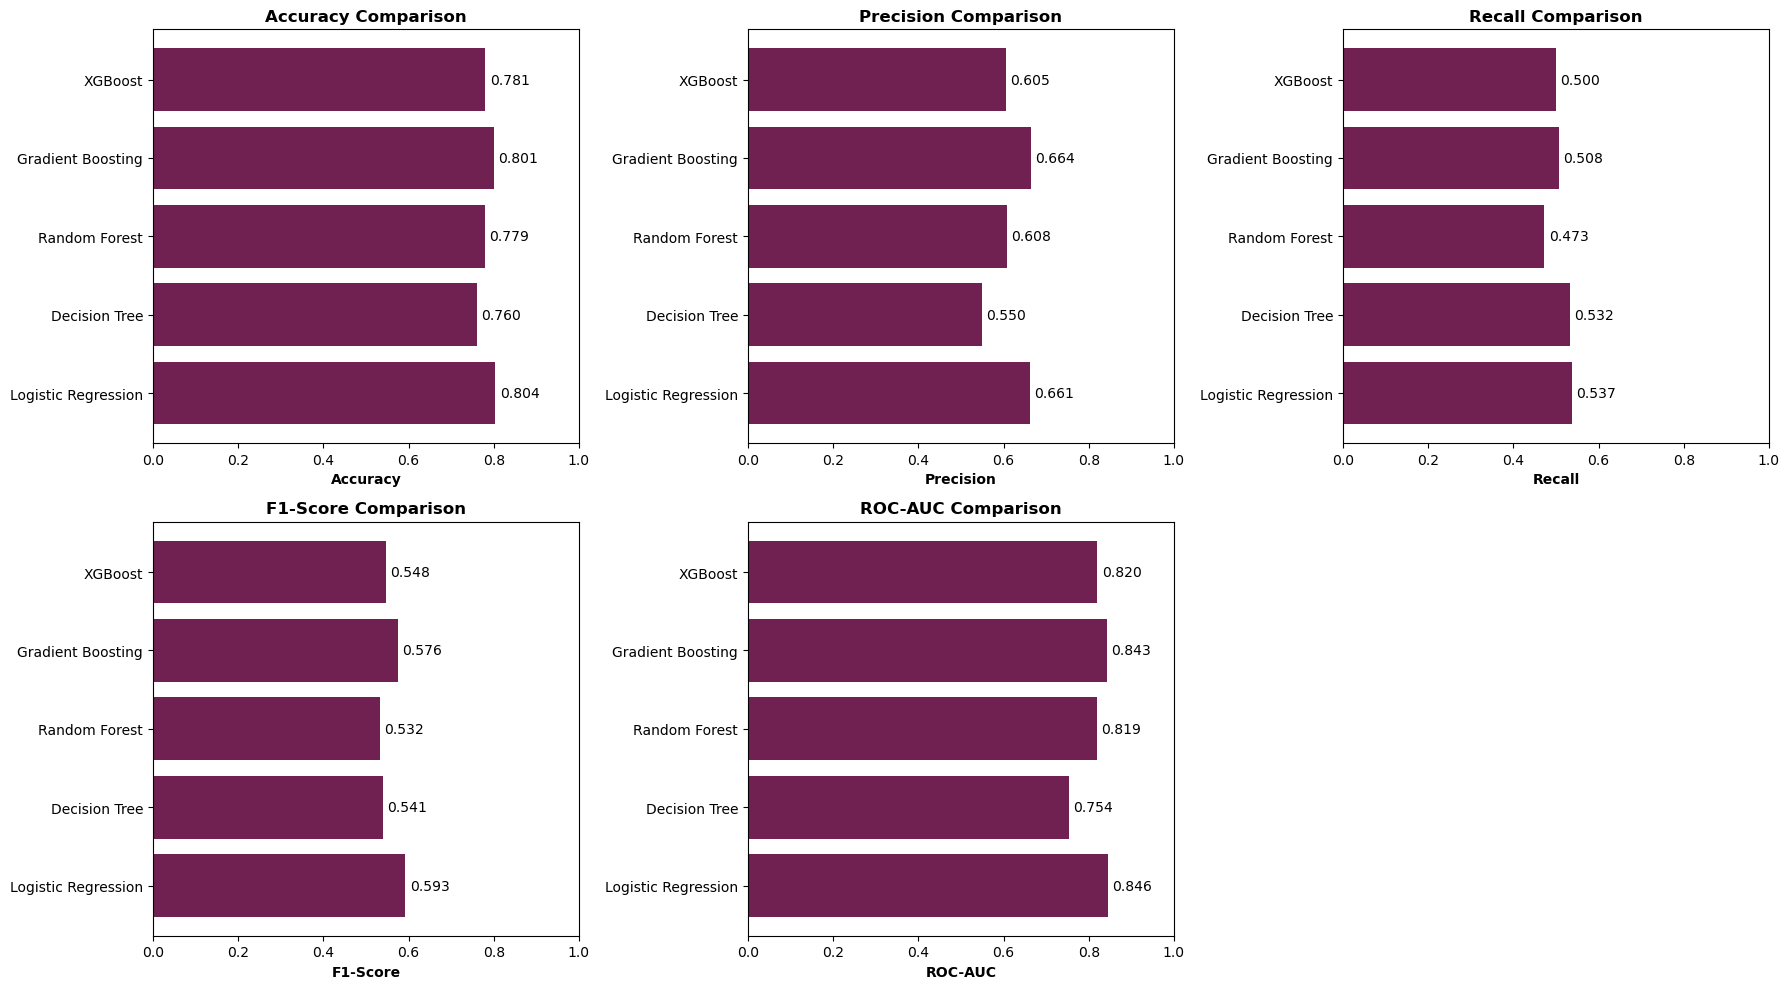

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(18,10))
axes = axes.flatten()

metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC']
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']

for idx, (metric, metric_name) in enumerate(zip(metrics, metrics_names)):
    
    values = [results[m][metric] for m in results]
    model_names = list(results.keys())
    
    axes[idx].barh(model_names, values, color="#702152")
    axes[idx].set_xlabel(metric_name, fontweight = 'bold')
    axes[idx].set_xlim(0,1)
    axes[idx].set_title(f'{metric_name} Comparison', fontweight = 'bold')
    

    
    for i, v in enumerate(values):
        axes[idx].text(v + 0.01, i, f'{v:.3f}', va='center')
    
    
    
    
    
fig.delaxes(axes[5])
plt.tight_layout()
plt.savefig('../reports/model_comparison_graph.png', dpi=300, bbox_inches='tight')
plt.show()

In [17]:
best_model_name = model_compare.iloc[0]['Model']
best_model_result = results[best_model_name]

print(f"Best Model: {best_model_name}")

Best Model: Logistic Regression


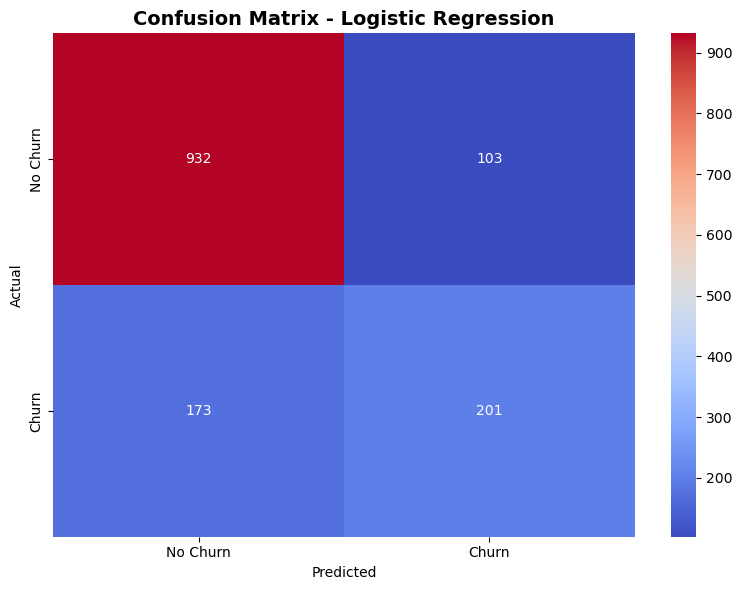

✅ Saved: reports/confusion_matrix.png


In [18]:
cm = confusion_matrix(y_test, best_model_result['y_pred'])

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='coolwarm',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])

plt.title(f'Confusion Matrix - {best_model_name}', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')


plt.tight_layout()
plt.savefig('../reports/confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Saved: reports/confusion_matrix.png")

In [19]:
print(classification_report(y_test, best_model_result['y_pred'], target_names=['No Churn', 'Churn']))

              precision    recall  f1-score   support

    No Churn       0.84      0.90      0.87      1035
       Churn       0.66      0.54      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.80      0.80      0.80      1409



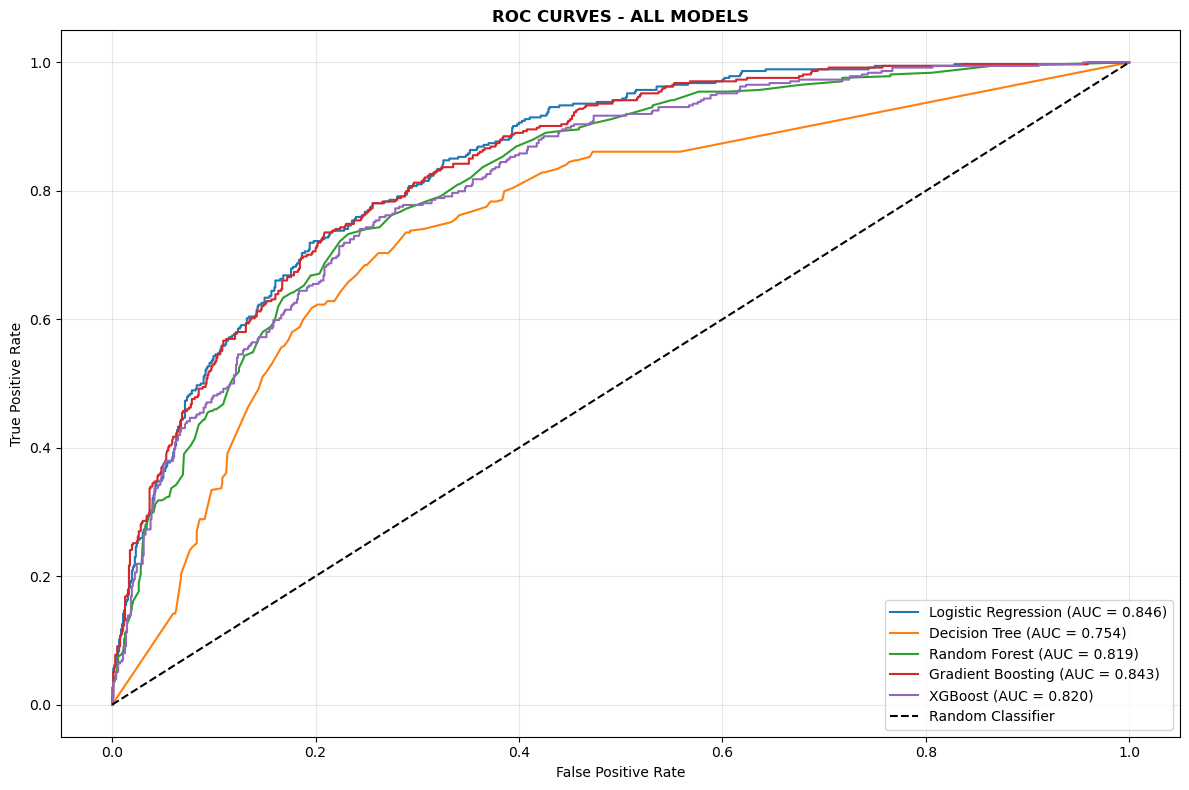

In [20]:
plt.figure(figsize=(12,8))

for name in results:
    fpr, tpr, _ = roc_curve(y_test, results[name]['y_pred_proba'])
    plt.plot(fpr, tpr, label=f"{name} (AUC = {results[name]['ROC AUC']:.3f})")
    
    
plt.plot([0,1], [0,1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC CURVES - ALL MODELS', fontweight = 'bold')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/roc_curves.png', dpi=300, bbox_inches='tight')

plt.show()

In [21]:
if hasattr(best_model_result['Model'], 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'Feature': X_train.columns,
        'Importance': best_model_result['Model'].feature_importances_
    }).sort_values('Importance', ascending=False).head(15)
    
    plt.figure(figsize=(12, 8))
    sns.barplot(data=feature_importance, y='Feature', x='Importance', palette='viridis')
    plt.title(f'Top 15 Feature Importance - {best_model_name}', fontsize=14, fontweight='bold')
    plt.xlabel('Importance Score', fontweight='bold')
    plt.tight_layout()
    plt.savefig('../reports/feature_importance.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✅ Saved: reports/feature_importance.png")
    print("\n📊 Top 10 Most Important Features:")
    print(feature_importance.head(10).to_string(index=False))
else:
    print(f"\n⚠️  {best_model_name} doesn't have feature_importances_ attribute")


⚠️  Logistic Regression doesn't have feature_importances_ attribute


In [24]:
import joblib

best_model = models[best_model_name]
model_path = f'../models/best_model_{best_model_name.replace(" ", "_").lower()}.pkl'

joblib.dump(best_model, model_path)
joblib.dump(preprocessor, '../models/preprocessor.pkl')
print("\n Model Saved")
print(f"Model Path : {model_path}")


 Model Saved
Model Path : ../models/best_model_logistic_regression.pkl


In [ ]:
print("\n" + "="*60)
print("PROJECT SUMMARY")
print("="*60)
print(f"\n🎯 Best Model: {best_model_name}")
print(f"   ROC-AUC Score: {best_model_result['ROC AUC']:.4f}")
print(f"   Accuracy: {best_model_result['Accuracy']:.4f}")
print(f"   F1-Score: {best_model_result['F1 Score']:.4f}")

print(f"\n📁 Generated Files:")
print("   - reports/model_comparison.csv")
print("   - reports/model_comparison_visual.png")
print("   - reports/confusion_matrix.png")
print("   - reports/roc_curves.png")
print("   - reports/feature_importance.png")
print("   - models/best_model_*.pkl")
print("   - models/preprocessor.pkl")

print("\n✅ PROJECT COMPLETE!")
print("="*60)


PROJECT SUMMARY

🎯 Best Model: Logistic Regression
   ROC-AUC Score: 0.8458
   Accuracy: 0.8041
   F1-Score: 0.5929

📁 Generated Files:
   - reports/model_comparison.csv
   - reports/model_comparison_visual.png
   - reports/confusion_matrix.png
   - reports/roc_curves.png
   - reports/feature_importance.png
   - models/best_model_*.pkl
   - models/preprocessor.pkl

✅ PROJECT COMPLETE!
